<span style="color:#44f;font-weight:bold;">Codes for CNS2025: Lecture 15</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Weight dynamics with saturation constraints

$$ \tau_w \frac{d\mathbf{w}}{dt} = \mathbf{Q}\cdot \mathbf{w} $$

In [2]:
# Input correlation matrix
Q = np.array([
    [1,-0.4],
    [-0.4,1]
])

In [3]:
l,vv = np.linalg.eigh(Q)
l,vv

(array([0.6, 1.4]),
 array([[-0.70710678, -0.70710678],
        [-0.70710678,  0.70710678]]))

In [4]:
l[0],vv[:,0]

(np.float64(0.6), array([-0.70710678, -0.70710678]))

In [5]:
l[1],vv[:,1]

(np.float64(1.4), array([-0.70710678,  0.70710678]))

$$ \mathbf{w}(t) = c_1 \begin{pmatrix} 1 \\ -1\end{pmatrix} e^{\lambda_1 t} + c_2 \begin{pmatrix} 1 \\ 1\end{pmatrix} e^{\lambda_2 t} $$

In [6]:
# Separation lines, consider trajectory that goes to the fixed points:
#  (1,0.4) and (0.4,1), we trace back to t=-10. 
ts = np.linspace(-10,0,100)
w1s = (1.4*np.exp(ts*0.6)-0.6*np.exp(ts*1.4))/2
w2s = (1.4*np.exp(ts*0.6)+0.6*np.exp(ts*1.4))/2

In [7]:
def get_w_trace(w0,dt=0.01):
    ''' Generate weight traces given initial weights
    '''
    w = np.array(w0)
    ws = []
    while (w[0]>0 and w[0]<1) or (w[1]>0 and w[1]<1):
        w1 = w+dt*Q@w
        w1 = w1*(w1>0) # Lower cutoff (component-wise rectification)
        w1 = w1-(w1-1)*(w1>1) # Upper cutoff
        ws.append(w1)
        if np.abs(w1-w).sum()<1e-10: break
        w = w1
    return np.array(ws)

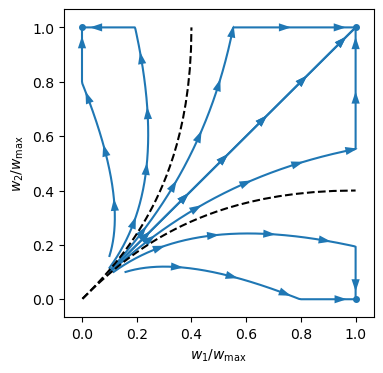

In [8]:
plt.figure(figsize=(4,4))
w01 = 0.1
for w02 in [0.1,0.104,0.115,0.158]: # Different initial points
    tr = get_w_trace([w01,w02]).T
    for xs,ys in [(tr[0],tr[1]),(tr[1],tr[0])]: # By symmetry 
        plt.plot(xs,ys,color='C0')
        # Draw arrows on the line
        x,y = xs[0],ys[0]
        px,py = x,y
        for xx,yy in zip(xs,ys):
            if (xx-x)**2+(yy-y)**2>0.04:
                dx = xx-px
                dy = yy-py
                r = np.sqrt(dx**2+dy**2)
                plt.arrow(xx,yy,0.01*dx/r,0.01*dy/r,length_includes_head=True,head_width=0.03,lw=0)
                x,y = xx,yy
            px,py = xx,yy
plt.plot([0,1,1],[1,1,0],'o',markersize=4) # Endpoints
plt.plot(w1s,w2s,'k--')
plt.plot(w2s,w1s,'k--')
plt.xlabel(r'$w_1/w_\max$')
plt.ylabel(r'$w_2/w_\max$')
plt.show()

## Principal components

In [9]:
rng = np.random.default_rng(123)
th = np.pi/4
rot = np.array([
    [np.cos(th),-np.sin(th)],
    [np.sin(th),np.cos(th)]
])
num = 256
dat = rng.multivariate_normal([0,0],np.diag([1,0.2]),size=num)@rot
[xs,ys] = dat.T

In [10]:
grs = []

In [11]:
Q = dat.T@dat/num # Correlation matrix
l,vv = np.linalg.eigh(Q)
e1 = vv[:,np.argmax(l)]
grs.append((dat,e1))

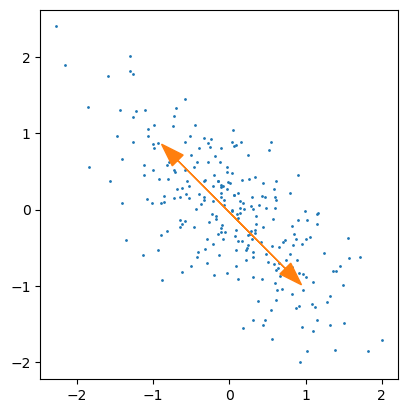

In [12]:
f,a = plt.subplots()
a.scatter(*dat.T,s=1)
a.arrow(*dat.mean(axis=0),*e1,head_width=0.2,color='C1')
a.arrow(*dat.mean(axis=0),*-e1,head_width=0.2,color='C1')
a.set_aspect(1)

In [13]:
dat = rng.multivariate_normal([0,0],np.diag([1,0.2]),size=num)@rot+np.array([2,2])

In [14]:
Q = dat.T@dat/num # Correlation matrix
l,vv = np.linalg.eigh(Q)
e1 = vv[:,np.argmax(l)]
grs.append((dat,e1))

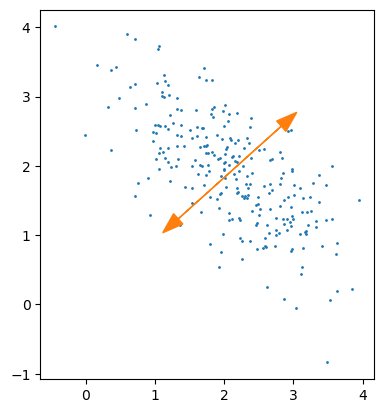

In [15]:
f,a = plt.subplots()
a.scatter(*dat.T,s=1)
a.arrow(*dat.mean(axis=0),*e1,head_width=0.2,color='C1')
a.arrow(*dat.mean(axis=0),*-e1,head_width=0.2,color='C1')
a.set_aspect(1)

In [16]:
dd = dat-dat.mean(axis=0)
C = dd.T@dd/num # Correlation matrix
l,vv = np.linalg.eigh(C)
e1 = vv[:,np.argmax(l)]
grs.append((dat,e1))

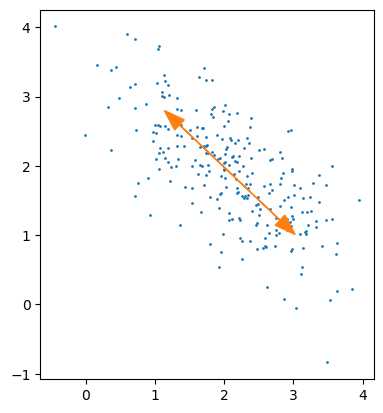

In [17]:
f,a = plt.subplots()
a.scatter(*dat.T,s=1)
a.arrow(*dat.mean(axis=0),*e1,head_width=0.2,color='C1')
a.arrow(*dat.mean(axis=0),*-e1,head_width=0.2,color='C1')
a.set_aspect(1)

In [18]:
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

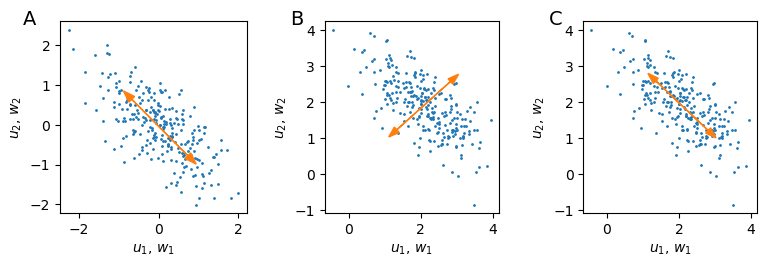

In [19]:
f,aa = plt.subplots(1,3,figsize=(10,2.5))
f.subplots_adjust(wspace=0)
for i,(dat,e1) in enumerate(grs):
    a = aa[i]
    a.scatter(*dat.T,s=1)
    a.arrow(*dat.mean(axis=0),*e1,head_width=0.2,color='C1')
    a.arrow(*dat.mean(axis=0),*-e1,head_width=0.2,color='C1')
    a.set_aspect(1)
    a.text(-0.2,0.98,['A','B','C'][i],fontsize=14,transform=a.transAxes)
    a.set_xlabel(r'$u_1$, $w_1$')
    a.set_ylabel(r'$u_2$, $w_2$')
plt.show()

## With subtractive normalization
\begin{equation*}
\mathbf{w}(t) = \left(\mathbf{w}(0)\cdot\mathbf{e}_1\right)\mathbf{e}_1 +
 \sum_{\mu=1}^{N_u}\exp\left(\frac{\lambda_\mu t}{\tau_w}\right)
 \left(\mathbf{w}(0)\cdot\mathbf{e}_\mu\right)\mathbf{e}_\mu
\end{equation*}

In [20]:
def gau(x,s):
    return np.exp(-x**2/s)

In [21]:
xs = np.arange(-1.2,1.2,0.01)
ks = gau(xs,0.01)-gau(xs,0.1)/10 # Difference of two Gaussians

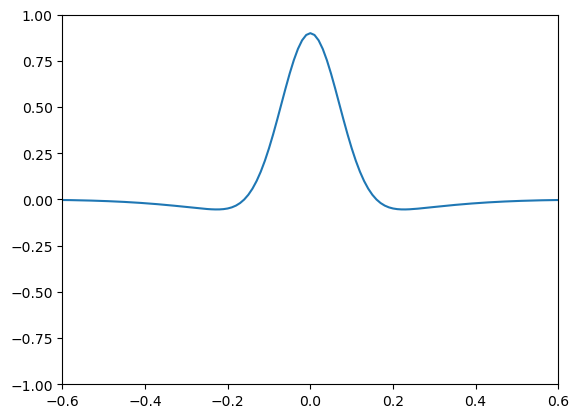

In [22]:
plt.plot(xs,ks)
plt.ylim(-1,1)
plt.xlim(-.6,.6)
plt.show()

In [23]:
from scipy.fft import fft,fftshift

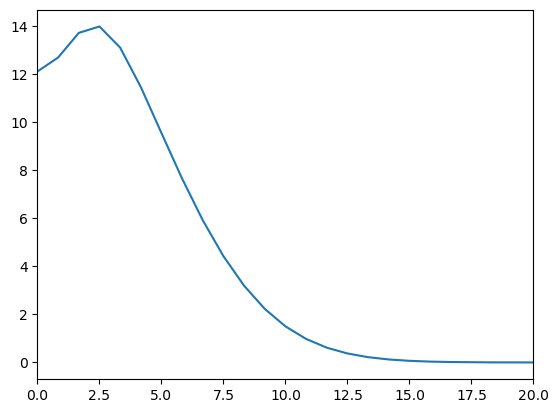

In [24]:
kk = fft(fftshift(ks))
plt.plot(np.arange(len(kk))/1.2,kk.real)
plt.xlim(0,20)
plt.show()

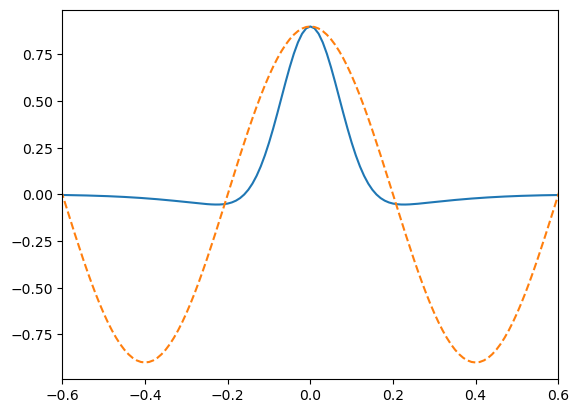

In [25]:
kp = fftshift(fft((kk==kk.max()))).real*.9 # Take the maximum mode and transform it back
plt.plot(xs,ks)
plt.plot(xs,kp,'--')
plt.xlim(-.6,.6)
plt.show()

<hr>
<address style="color:#44f;font-style:italic;font-weight:bold;"><a href="https://cc.tir.tw/wk/2025cns">CNS2025</a></address>